# 🛒 Pandas Assignment — E-Commerce Sales Analysis
### Olist Brazilian E-Commerce Dataset

Welcome to the practical assignment for the Pandas Complete Guide. You will perform a full end-to-end analysis of a real e-commerce company's sales data, applying every pandas technique covered in the lesson notebook.

---

## 🎯 Learning Objectives
By the end of this assignment you will have:
- **Loaded and merged** 7+ related CSV tables (orders, customers, products, sellers, payments, items, reviews)
- **Handled missing values** with multiple strategies based on context
- **Joined and merged** DataFrames using every join type (inner, left, right, outer)
- **Performed group-by aggregations** for business KPIs
- **Conducted time-series analysis** including resampling, rolling windows, and trend detection
- **Produced a final business report** with concrete, data-backed insights

---

## 📦 The Dataset

We use the **Olist Brazilian E-Commerce Public Dataset** — 100,000+ real (anonymized) orders from 2016–2018, organized across 9 interrelated tables. This is one of the most popular publicly available sales datasets and is widely used in data science portfolios.

### Schema overview
```
                  ┌─────────────┐
                  │  customers  │
                  └──────┬──────┘
                         │ customer_id
                  ┌──────▼──────┐
        ┌────────►│   orders    │◄────────┐
        │         └──────┬──────┘         │
        │ order_id       │ order_id       │ order_id
┌───────┴──────┐  ┌──────▼─────┐   ┌──────┴────────┐
│   reviews    │  │ order_items │   │   payments   │
└──────────────┘  └─┬─────────┬─┘   └──────────────┘
                    │         │
              product_id   seller_id
                    │         │
              ┌─────▼───┐ ┌───▼────┐
              │ products│ │ sellers│
              └─────────┘ └────────┘
```

### 📥 How to obtain the dataset

**Option A — Real Olist data (recommended for portfolio work):**
1. Visit https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce
2. Sign in to Kaggle (free) and click **Download** to get `archive.zip` (~45 MB)
3. Extract and place all CSV files into a folder named `olist_data/` in the same directory as this notebook
4. Set `USE_REAL_DATA = True` in the setup cell below

**Option B — Synthetic equivalent (run immediately):**
- Leave `USE_REAL_DATA = False` (default)
- The notebook will generate a smaller synthetic dataset with the same schema and column names
- All assignment questions and code work identically on both datasets

> **Tip:** start with Option B to build your code. If you want to extend the work into a portfolio piece, swap to Option A — your code will keep working on the larger real dataset.

---

## 📝 How to Submit

Fill in every code cell marked `# Your code here`. Add markdown cells with your interpretation wherever a question asks **"explain"** or **"comment"**.

Each section has its own **rubric** at the top — check yourself before moving on.

> ⏱ **Estimated time:** 6–10 hours of focused work depending on depth of exploration.

---
## 🔧 Setup

Run these cells first. They import libraries and either load the real Olist files or generate synthetic equivalents.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 120)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (11, 5)

# ────────────────────────────────────────────────────────────────────
# SWITCH BETWEEN REAL OLIST DATA AND SYNTHETIC DATA
# ────────────────────────────────────────────────────────────────────
USE_REAL_DATA = True   # set to True if you've downloaded Olist from Kaggle
DATA_DIR = 'dataset/'  # folder containing the Olist CSVs (real data only)

print(f"USE_REAL_DATA = {USE_REAL_DATA}")
print(f"pandas = {pd.__version__}")

USE_REAL_DATA = True
pandas = 2.3.3


### Synthetic data generator (only runs if `USE_REAL_DATA = False`)

This builds 7 CSV files with the same column names as the real Olist dataset. Records are interrelated and span 2 years so the time-series questions are meaningful.

In [7]:
import os

if not USE_REAL_DATA:
    rng = np.random.default_rng(42)
    os.makedirs('synthetic_olist', exist_ok=True)

    # ── 1. CUSTOMERS ────────────────────────────────────────────────
    n_customers = 3000
    states = ['SP','RJ','MG','RS','PR','SC','BA','DF','GO','PE','CE','PA','MA','MT','MS']
    state_p = [0.42,0.13,0.12,0.06,0.05,0.04,0.04,0.03,0.03,0.02,0.02,0.01,0.01,0.01,0.01]
    cities = {
        'SP':['sao paulo','campinas','santos','ribeirao preto','sorocaba'],
        'RJ':['rio de janeiro','niteroi','duque de caxias'],
        'MG':['belo horizonte','uberlandia','contagem','juiz de fora'],
        'RS':['porto alegre','caxias do sul','pelotas'],
        'PR':['curitiba','londrina','maringa'],
        'SC':['florianopolis','joinville','blumenau'],
        'BA':['salvador','feira de santana'],
        'DF':['brasilia'],
        'GO':['goiania','aparecida de goiania'],
        'PE':['recife','olinda'],
        'CE':['fortaleza','caucaia'],
        'PA':['belem','ananindeua'],
        'MA':['sao luis'],
        'MT':['cuiaba','varzea grande'],
        'MS':['campo grande'],
    }
    cust_states = rng.choice(states, n_customers, p=state_p)
    customers = pd.DataFrame({
        'customer_id': [f'cust_{i:06d}' for i in range(n_customers)],
        'customer_unique_id': [f'uniq_{rng.integers(0, n_customers*0.85):06d}' for _ in range(n_customers)],
        'customer_zip_code_prefix': rng.integers(1000, 99999, n_customers),
        'customer_city': [rng.choice(cities[s]) for s in cust_states],
        'customer_state': cust_states,
    })
    customers.to_csv('synthetic_olist/olist_customers_dataset.csv', index=False)

    # ── 2. SELLERS ──────────────────────────────────────────────────
    n_sellers = 250
    sel_states = rng.choice(states, n_sellers, p=state_p)
    sellers = pd.DataFrame({
        'seller_id': [f'sell_{i:04d}' for i in range(n_sellers)],
        'seller_zip_code_prefix': rng.integers(1000, 99999, n_sellers),
        'seller_city': [rng.choice(cities[s]) for s in sel_states],
        'seller_state': sel_states,
    })
    sellers.to_csv('synthetic_olist/olist_sellers_dataset.csv', index=False)

    # ── 3. PRODUCTS ────────────────────────────────────────────────
    n_products = 800
    categories = ['cama_mesa_banho','beleza_saude','esporte_lazer','informatica_acessorios',
                  'moveis_decoracao','utilidades_domesticas','relogios_presentes','telefonia',
                  'automotivo','brinquedos','cool_stuff','ferramentas_jardim','perfumaria',
                  'bebes','eletronicos','livros_interesse_geral']
    products = pd.DataFrame({
        'product_id': [f'prod_{i:05d}' for i in range(n_products)],
        'product_category_name': rng.choice(categories, n_products),
        'product_name_lenght': rng.integers(20, 80, n_products).astype(float),
        'product_description_lenght': rng.integers(100, 4000, n_products).astype(float),
        'product_photos_qty': rng.integers(1, 8, n_products).astype(float),
        'product_weight_g': rng.integers(50, 30000, n_products).astype(float),
        'product_length_cm': rng.integers(10, 100, n_products).astype(float),
        'product_height_cm': rng.integers(2, 80, n_products).astype(float),
        'product_width_cm': rng.integers(5, 80, n_products).astype(float),
    })
    # Inject realistic missingness
    for col in ['product_category_name','product_weight_g','product_length_cm','product_height_cm','product_width_cm']:
        miss_idx = rng.choice(n_products, size=int(n_products*0.03), replace=False)
        products.loc[miss_idx, col] = np.nan
    products.to_csv('synthetic_olist/olist_products_dataset.csv', index=False)

    # ── 4. ORDERS ────────────────────────────────────────────────
    n_orders = 7000
    # Build datetime distribution: increasing volume over time + weekly seasonality
    start = pd.Timestamp('2017-01-01')
    days_range = 730
    # weight days so volume grows over time and dips on weekends slightly
    day_weights = []
    for d in range(days_range):
        date = start + pd.Timedelta(days=d)
        base = 0.5 + d/days_range  # linear growth
        if date.weekday() in [5, 6]:
            base *= 0.85  # slightly lower weekend volume
        # holiday spike around November (Black Friday)
        if date.month == 11 and 20 <= date.day <= 28:
            base *= 2.5
        day_weights.append(base)
    day_weights = np.array(day_weights) / sum(day_weights)
    chosen_days = rng.choice(days_range, n_orders, p=day_weights)
    purchase_ts = [start + pd.Timedelta(days=int(d), hours=int(rng.integers(8,23)),
                                         minutes=int(rng.integers(0,60))) for d in chosen_days]
    purchase_ts = pd.to_datetime(purchase_ts)

    statuses = rng.choice(['delivered','shipped','canceled','invoiced','processing'],
                           n_orders, p=[0.92, 0.03, 0.03, 0.01, 0.01])
    approved_ts = [t + pd.Timedelta(hours=int(rng.integers(0,48))) for t in purchase_ts]
    carrier_ts = [t + pd.Timedelta(days=int(rng.integers(1,7))) for t in approved_ts]
    delivered_ts = [t + pd.Timedelta(days=int(rng.integers(2,15))) for t in carrier_ts]
    estimated_ts = [t + pd.Timedelta(days=int(rng.integers(10,25))) for t in purchase_ts]

    orders = pd.DataFrame({
        'order_id': [f'ord_{i:06d}' for i in range(n_orders)],
        'customer_id': rng.choice(customers['customer_id'], n_orders),
        'order_status': statuses,
        'order_purchase_timestamp': purchase_ts,
        'order_approved_at': approved_ts,
        'order_delivered_carrier_date': carrier_ts,
        'order_delivered_customer_date': delivered_ts,
        'order_estimated_delivery_date': estimated_ts,
    })
    # Inject missingness: non-delivered orders have missing delivery dates
    orders.loc[orders['order_status'] != 'delivered', 'order_delivered_customer_date'] = pd.NaT
    orders.loc[orders['order_status'].isin(['canceled','processing','invoiced']),
               'order_delivered_carrier_date'] = pd.NaT
    # A few approved_at missing too
    miss_idx = rng.choice(n_orders, size=int(n_orders*0.005), replace=False)
    orders.loc[miss_idx, 'order_approved_at'] = pd.NaT
    orders.to_csv('synthetic_olist/olist_orders_dataset.csv', index=False)

    # ── 5. ORDER ITEMS ────────────────────────────────────────────────
    item_rows = []
    for i, oid in enumerate(orders['order_id']):
        n_items = rng.choice([1, 1, 1, 1, 2, 2, 3], p=[0.55,0.15,0.05,0.05,0.12,0.05,0.03])
        purchase_t = orders.iloc[i]['order_purchase_timestamp']
        for item_n in range(1, n_items + 1):
            price = round(float(rng.lognormal(4.3, 0.7)), 2)
            freight = round(price * float(rng.uniform(0.05, 0.25)), 2)
            item_rows.append({
                'order_id': oid,
                'order_item_id': item_n,
                'product_id': rng.choice(products['product_id']),
                'seller_id': rng.choice(sellers['seller_id']),
                'shipping_limit_date': purchase_t + pd.Timedelta(days=int(rng.integers(2, 8))),
                'price': price,
                'freight_value': freight,
            })
    order_items = pd.DataFrame(item_rows)
    order_items.to_csv('synthetic_olist/olist_order_items_dataset.csv', index=False)

    # ── 6. PAYMENTS ──────────────────────────────────────────────────
    payment_rows = []
    for oid in orders['order_id']:
        n_pay = rng.choice([1, 1, 1, 2], p=[0.92, 0.04, 0.02, 0.02])
        order_total = order_items[order_items['order_id'] == oid][['price','freight_value']].sum().sum()
        for seq in range(1, n_pay + 1):
            pay_type = rng.choice(['credit_card','boleto','voucher','debit_card'], p=[0.74,0.19,0.05,0.02])
            installments = rng.choice([1,2,3,4,5,6,8,10], p=[0.5,0.12,0.10,0.08,0.06,0.05,0.05,0.04]) if pay_type=='credit_card' else 1
            payment_rows.append({
                'order_id': oid,
                'payment_sequential': seq,
                'payment_type': pay_type,
                'payment_installments': int(installments),
                'payment_value': round(float(order_total / n_pay), 2),
            })
    payments = pd.DataFrame(payment_rows)
    payments.to_csv('synthetic_olist/olist_order_payments_dataset.csv', index=False)

    # ── 7. REVIEWS ──────────────────────────────────────────────────
    review_rows = []
    for i, oid in enumerate(orders['order_id']):
        if rng.random() < 0.85:  # 85% have a review
            score = rng.choice([1,2,3,4,5], p=[0.10, 0.05, 0.10, 0.20, 0.55])
            create_ts = orders.iloc[i]['order_purchase_timestamp'] + pd.Timedelta(days=int(rng.integers(5,25)))
            answer_ts = create_ts + pd.Timedelta(days=int(rng.integers(0,10))) if rng.random() < 0.7 else pd.NaT
            review_rows.append({
                'review_id': f'rev_{i:06d}',
                'order_id': oid,
                'review_score': int(score),
                'review_comment_title': rng.choice(['Excelente','Bom','Recomendo','Péssimo','Otimo', None],
                                                   p=[0.15,0.15,0.10,0.05,0.10,0.45]),
                'review_comment_message': rng.choice(['Produto chegou rapido','Recomendo a todos',
                                                       'Produto com defeito','Atrasou a entrega',
                                                       'Otima qualidade', None],
                                                      p=[0.18,0.12,0.05,0.05,0.15,0.45]),
                'review_creation_date': create_ts,
                'review_answer_timestamp': answer_ts,
            })
    reviews = pd.DataFrame(review_rows)
    reviews.to_csv('synthetic_olist/olist_order_reviews_dataset.csv', index=False)

    # ── 8. CATEGORY TRANSLATION ──────────────────────────────────────
    translation = pd.DataFrame({
        'product_category_name': categories,
        'product_category_name_english': [
            'bed_bath_table','health_beauty','sports_leisure','computers_accessories',
            'furniture_decor','housewares','watches_gifts','telephony',
            'auto','toys','cool_stuff','garden_tools','perfumery',
            'baby','electronics','books_general_interest'
        ],
    })
    translation.to_csv('synthetic_olist/product_category_name_translation.csv', index=False)

    DATA_DIR = 'synthetic_olist/'
    print('✅ Synthetic dataset generated in:', DATA_DIR)
    print('Files written:')
    for f in sorted(os.listdir(DATA_DIR)):
        print(f'   {f}  ({os.path.getsize(DATA_DIR + f)/1024:.1f} KB)')

### Load all the CSVs

In [4]:
customers      = pd.read_csv(DATA_DIR + 'olist_customers_dataset.csv')
orders         = pd.read_csv(DATA_DIR + 'olist_orders_dataset.csv')
order_items    = pd.read_csv(DATA_DIR + 'olist_order_items_dataset.csv')
products       = pd.read_csv(DATA_DIR + 'olist_products_dataset.csv')
sellers        = pd.read_csv(DATA_DIR + 'olist_sellers_dataset.csv')
payments       = pd.read_csv(DATA_DIR + 'olist_order_payments_dataset.csv')
reviews        = pd.read_csv(DATA_DIR + 'olist_order_reviews_dataset.csv')
translation    = pd.read_csv(DATA_DIR + 'product_category_name_translation.csv')

# Parse datetime columns up front
for col in ['order_purchase_timestamp','order_approved_at',
            'order_delivered_carrier_date','order_delivered_customer_date',
            'order_estimated_delivery_date']:
    orders[col] = pd.to_datetime(orders[col], errors='coerce')

reviews['review_creation_date']     = pd.to_datetime(reviews['review_creation_date'])
reviews['review_answer_timestamp']  = pd.to_datetime(reviews['review_answer_timestamp'], errors='coerce')
order_items['shipping_limit_date']  = pd.to_datetime(order_items['shipping_limit_date'])

print('All 8 tables loaded:')
for name, t in [('customers',customers),('orders',orders),('order_items',order_items),
                ('products',products),('sellers',sellers),('payments',payments),
                ('reviews',reviews),('translation',translation)]:
    print(f'  {name:15s} {t.shape}')

All 8 tables loaded:
  customers       (3000, 5)
  orders          (7000, 8)
  order_items     (8593, 7)
  products        (800, 9)
  sellers         (250, 4)
  payments        (7139, 5)
  reviews         (5963, 7)
  translation     (16, 2)


---
# Part 1 — Data Loading & Inspection

> **Rubric:** for each table you should be able to state (a) what one row represents, (b) the primary key, (c) the foreign keys that link to other tables, (d) the data types of each column, (e) the count of missing values per column.

### Q1.1 — Display the first 5 rows of every table.

In [5]:
# Display first 5 rows of every table
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,cust_000000,uniq_001578,45150,londrina,PR
1,cust_000001,uniq_002114,2866,niteroi,RJ
2,cust_000002,uniq_001632,67639,salvador,BA
3,cust_000003,uniq_001514,46046,porto alegre,RS
4,cust_000004,uniq_001191,77383,santos,SP


In [8]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,ord_000000,cust_001767,delivered,2018-10-14 18:44:00,2018-10-14 18:44:00,2018-10-19 18:44:00,2018-10-23 18:44:00,2018-11-01 18:44:00
1,ord_000001,cust_002696,delivered,2018-08-27 15:38:00,2018-08-27 17:38:00,2018-08-28 17:38:00,2018-09-02 17:38:00,2018-09-18 15:38:00
2,ord_000002,cust_000938,delivered,2018-05-30 16:41:00,2018-05-31 18:41:00,2018-06-02 18:41:00,2018-06-07 18:41:00,2018-06-20 16:41:00
3,ord_000003,cust_002656,delivered,2018-02-16 14:39:00,2018-02-17 14:39:00,2018-02-22 14:39:00,2018-02-27 14:39:00,2018-03-05 14:39:00
4,ord_000004,cust_001532,delivered,2018-09-06 17:38:00,2018-09-07 08:38:00,2018-09-08 08:38:00,2018-09-14 08:38:00,2018-09-17 17:38:00


In [11]:
order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,ord_000000,1,prod_00658,sell_0139,2018-10-18 18:44:00,115.30,19.73
1,ord_000000,2,prod_00707,sell_0165,2018-10-19 18:44:00,75.39,4.15
2,ord_000001,1,prod_00063,sell_0188,2018-09-03 15:38:00,94.17,18.35
3,ord_000001,2,prod_00154,sell_0051,2018-09-03 15:38:00,20.08,3.52
4,ord_000002,1,prod_00415,sell_0215,2018-06-02 16:41:00,138.35,27.24


### Q1.2 — For each table, print `.shape`, `.dtypes`, and `.info()`.

In [4]:
# Print shape, dtypes, and info for each table
tables = [
    ("customers", customers),
    ("orders", orders),
    ("order_items", order_items),
    ("products", products),
    ("sellers", sellers),
    ("payments", payments),
    ("reviews", reviews),
    ("translation", translation)
]
for name, df in tables:
    print(f"Table name: {name}")
    print(f".shape: {df.shape}")
    print(f".dtypes: {df.dtypes}")
    df.info()

Table name: customers
.shape: (3000, 5)
.dtypes: customer_id                 object
customer_unique_id          object
customer_zip_code_prefix     int64
customer_city               object
customer_state              object
dtype: object
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               3000 non-null   object
 1   customer_unique_id        3000 non-null   object
 2   customer_zip_code_prefix  3000 non-null   int64 
 3   customer_city             3000 non-null   object
 4   customer_state            3000 non-null   object
dtypes: int64(1), object(4)
memory usage: 117.3+ KB
Table name: orders
.shape: (7000, 8)
.dtypes: order_id                                 object
customer_id                              object
order_status                             object
order_purchase_timestamp         dat

### Q1.3 — Identify keys
For each table, write down (as a markdown comment in a cell below) what the **primary key** is and what **foreign keys** link it to other tables.

For example, in `orders`:
- Primary key: `order_id`
- Foreign keys: `customer_id` → `customers`

In [23]:
# Identification of primary keys and foreign keys for each table:
# - customers: PK is customer_id, no FKs present.
# - orders: PK is order_id, FK is customer_id -> customers table.
# - order_items: PK is compound (order_id, order_item_id), FKs are order_id -> orders, product_id -> products, seller_id -> sellers.
# - products: PK is product_id, FK is product_category_name -> translation table.
# - sellers: PK is seller_id, no FKs present.
# - payments: PK is compound (order_id, payment_sequential), FK is order_id -> orders table.
# - reviews: PK is review_id, FK is order_id -> orders table.
# - translation: PK is product_category_name, no FKs present.

### Q1.4 — How many unique customers, sellers, products, and orders are there?
Use `.nunique()` rather than `len()` — they differ if a table has duplicates.

In [35]:
# Unique customers, sellers, products, and orders
print(customers['customer_unique_id'].nunique())

1767


In [38]:
print(sellers['seller_id'].nunique())

250


In [40]:
print(products['product_id'].nunique())

800


In [42]:
print(orders['order_id'].nunique())

7000


### Q1.5 — What date range does the dataset cover?
Compute the min and max of `order_purchase_timestamp` and the total span in days.

In [44]:
# Date range and total span in days
min_date = orders['order_purchase_timestamp'].min()
min_date

Timestamp('2017-01-01 10:08:00')

In [46]:
max_date = orders['order_purchase_timestamp'].max()
max_date

Timestamp('2018-12-31 21:44:00')

In [47]:
total_span_days = (max_date - min_date)
total_span_days

Timedelta('729 days 11:36:00')

### Q1.6 — Memory usage
Compute the **total memory** used by all 8 DataFrames combined. Which table uses the most memory?

In [49]:
# Compute memory usage of each table
total_memory = 0
for name, df in tables:
    memory = df.memory_usage(deep=True).sum()
    total_memory += memory

In [54]:
total_memory

np.int64(6646866)

In [59]:
largest_table = ""
largest_memory = 0

for name, df in tables:
    memory = df.memory_usage(deep=True).sum()

    if memory > largest_memory:
        largest_memory = memory
        largest_table = name
print(largest_table)
print(largest_memory)

order_items
1787476


### Q1.7 — Order status distribution
What are the unique values of `order_status` in the orders table, and how many rows fall into each? Sort by count, descending. What proportion of orders were ultimately delivered?

In [63]:
unique_order_status = orders['order_status'].unique()
unique_order_status

array(['delivered', 'canceled', 'shipped', 'processing', 'invoiced'],
      dtype=object)

order_status
delivered     6448
canceled       224
shipped        191
invoiced        72
processing      65
Name: count, dtype: int64

Proportion delivered: 92.11%


In [64]:
orders['order_status'].value_counts()

order_status
delivered     6448
canceled       224
shipped        191
invoiced        72
processing      65
Name: count, dtype: int64

In [69]:
orders['order_status'].value_counts().sort_values(ascending=False) 

order_status
delivered     6448
canceled       224
shipped        191
invoiced        72
processing      65
Name: count, dtype: int64

In [71]:
orders['order_status'].value_counts().sort_values(ascending=True)

order_status
processing      65
invoiced        72
shipped        191
canceled       224
delivered     6448
Name: count, dtype: int64

---
# Part 2 — Handling Missing Values

> **Rubric:** for every column that has missing values, you should be able to justify *why* it's missing and *what* you do about it. There is no single right answer — context matters.

### Q2.1 — Build a missing-value summary
Produce a DataFrame with one row per (table, column) pair where missing values exist. Columns: `table`, `column`, `n_missing`, `pct_missing`. Sort descending by `pct_missing`.

**Hint:**
```python
summary = []
for name, t in [('customers', customers), ('orders', orders), ...]:
    miss = t.isna().sum()
    for col, n in miss[miss > 0].items():
        summary.append({'table': name, 'column': col, 'n_missing': n, 'pct_missing': n/len(t)*100})
pd.DataFrame(summary).sort_values('pct_missing', ascending=False)
```

In [8]:
summary = []

for name, t in [
    ('customers', customers),
    ('orders', orders),
    ('order_items', order_items),
    ('products', products),
    ('sellers', sellers),
    ('payments', payments),
    ('reviews', reviews),
    ('translation', translation)
]:
    miss = t.isna().sum()
    for col, n in miss[miss>0].items():
        summary.append({
            'table': name,
            'column':col,
            'n_missing':n,
            'pct_missing':n/len(t)*100})
pd.DataFrame(summary).sort_values('pct_missing', ascending=False)

,table,column,n_missing,pct_missing
8,reviews,review_comment_title,2703,45.329532
9,reviews,review_comment_message,2633,44.155626
10,reviews,review_answer_timestamp,1744,29.247023
2,orders,order_delivered_customer_date,552,7.885714
1,orders,order_delivered_carrier_date,361,5.157143
3,products,product_category_name,24,3.000000
4,products,product_weight_g,24,3.000000
5,products,product_length_cm,24,3.000000
6,products,product_height_cm,24,3.000000
7,products,product_width_cm,24,3.000000


### Q2.2 — Visualize the missing-value pattern in `orders`
Build a heatmap of `orders.isna()`. Comment on what you see.

In [12]:
# Heatmap of orders.isna()
orders.isna().sum()

order_id                           0
customer_id                        0
order_status                       0
order_purchase_timestamp           0
order_approved_at                 35
order_delivered_carrier_date     361
order_delivered_customer_date    552
order_estimated_delivery_date      0
dtype: int64

In [13]:
orders.isna()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...
6995,False,False,False,False,False,False,False,False
6996,False,False,False,False,False,False,False,False
6997,False,False,False,False,False,False,False,False
6998,False,False,False,False,False,False,False,False


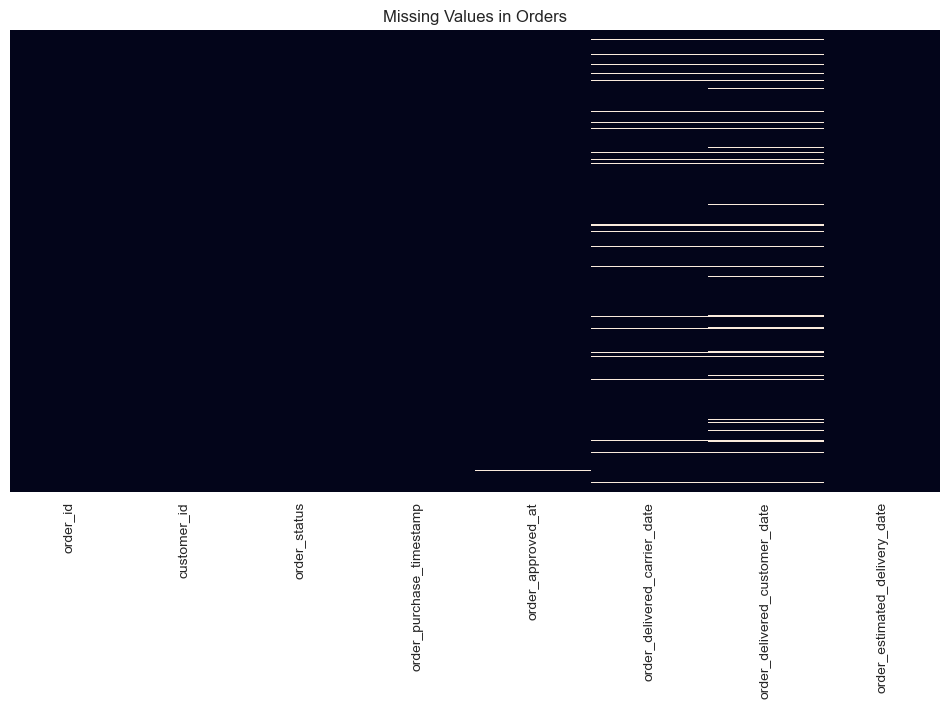

In [15]:
plt.figure(figsize=(12, 6))

sns.heatmap(
    orders.isna(),
    cbar=False,
    yticklabels=False
)

plt.title("Missing Values in Orders")
plt.show()

### Q2.3 — Explain the missingness in `orders.order_delivered_customer_date`
Group the orders DataFrame by `order_status` and count how many rows have `order_delivered_customer_date` missing for each status. Write a one-sentence interpretation: **why** would non-delivered orders have a missing delivery date?

In [27]:
orders['order_status'].value_counts()

order_status
delivered     6448
canceled       224
shipped        191
invoiced        72
processing      65
Name: count, dtype: int64

In [32]:
orders.groupby('order_status')['order_delivered_customer_date'].apply(lambda x: x.isna().sum())

order_status
canceled      224
delivered       0
invoiced       72
processing     65
shipped       191
Name: order_delivered_customer_date, dtype: int64

### Q2.4 — Impute `order_approved_at`
A small number of rows have a missing `order_approved_at` despite being delivered. Impute these with the **mean approval delay** (mean of `order_approved_at - order_purchase_timestamp`) added to the purchase timestamp. Verify there are no more missing approved-at values among delivered orders afterwards.

In [69]:
approved_orders = orders[orders['order_approved_at'].notna()]

In [71]:
approval_delay = (approved_orders['order_approved_at'] - approved_orders['order_purchase_timestamp'])

In [72]:
mean_approval_delay = approval_delay.mean()
mean_approval_delay

Timedelta('0 days 23:13:16.496769562')

In [74]:
missing_approved_delivered = orders[
    (orders['order_status'] == 'delivered') &
    (orders['order_approved_at'].isna())
]

In [75]:
missing_approved_delivered.shape

(0, 8)

In [76]:
orders.loc[
    (orders['order_status'] == 'delivered') &
    (orders['order_approved_at'].isna()),
    'order_approved_at'
] = (
    orders.loc[
        (orders['order_status'] == 'delivered') &
        (orders['order_approved_at'].isna()),
        'order_purchase_timestamp'
    ] + mean_approval_delay
)

In [77]:
orders.loc[
    orders['order_status'] == 'delivered',
    'order_approved_at'
].isna().sum()

np.int64(0)

### Q2.5 — Decide what to do about missing `product_category_name`
A few products are missing their category name. Show how many. Pick one of these strategies and apply it:
- (a) Fill with `'unknown'`
- (b) Drop those rows
- (c) Impute based on similar products (advanced)

Justify your choice in a comment.

In [5]:
products['product_category_name'].isna().sum()

np.int64(24)

In [7]:
products['product_category_name'] = products['product_category_name'].fillna("unknown")

In [8]:
products['product_category_name'].isna().sum()

np.int64(0)

### Q2.6 — Missing review comments
Reviews have many missing `review_comment_message` values. Is this missingness **informative** (do customers without comments give different scores than customers with comments)? Test this by computing the mean `review_score` for each group.

In [9]:
reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5963 entries, 0 to 5962
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   review_id                5963 non-null   object        
 1   order_id                 5963 non-null   object        
 2   review_score             5963 non-null   int64         
 3   review_comment_title     3260 non-null   object        
 4   review_comment_message   3330 non-null   object        
 5   review_creation_date     5963 non-null   datetime64[ns]
 6   review_answer_timestamp  4219 non-null   datetime64[ns]
dtypes: datetime64[ns](2), int64(1), object(4)
memory usage: 326.2+ KB


In [10]:
reviews.groupby(reviews['review_comment_message'].isna())['review_score'].mean()

review_comment_message
False    4.011712
True     4.064185
Name: review_score, dtype: float64

In [11]:
reviews.groupby(reviews['review_comment_message'].notna())['review_score'].mean()

review_comment_message
False    4.064185
True     4.011712
Name: review_score, dtype: float64

---
# Part 3 — Merging & Joining Datasets

> **Rubric:** you should choose the right join type for each task, predict the resulting row count before merging, and verify it after.

### Q3.1 — Inner join: orders + customers
Inner-join `orders` with `customers` on `customer_id`. How many rows result? Are there any orphan rows (orders without a customer, or vice versa)? Use `indicator=True` to check.

In [13]:
predicted_rows = len(orders)
predicted_rows

7000

In [14]:
# inner join order and customer
order_cust_inner = pd.merge(orders, customers, on="customer_id", how="inner")
order_cust_inner

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,ord_000000,cust_001767,delivered,2018-10-14 18:44:00,2018-10-14 18:44:00,2018-10-19 18:44:00,2018-10-23 18:44:00,2018-11-01 18:44:00,uniq_001182,19705,campinas,SP
1,ord_000001,cust_002696,delivered,2018-08-27 15:38:00,2018-08-27 17:38:00,2018-08-28 17:38:00,2018-09-02 17:38:00,2018-09-18 15:38:00,uniq_001856,71014,joinville,SC
2,ord_000002,cust_000938,delivered,2018-05-30 16:41:00,2018-05-31 18:41:00,2018-06-02 18:41:00,2018-06-07 18:41:00,2018-06-20 16:41:00,uniq_002024,62164,goiania,GO
3,ord_000003,cust_002656,delivered,2018-02-16 14:39:00,2018-02-17 14:39:00,2018-02-22 14:39:00,2018-02-27 14:39:00,2018-03-05 14:39:00,uniq_000961,35098,ribeirao preto,SP
4,ord_000004,cust_001532,delivered,2018-09-06 17:38:00,2018-09-07 08:38:00,2018-09-08 08:38:00,2018-09-14 08:38:00,2018-09-17 17:38:00,uniq_002125,73421,uberlandia,MG
...,...,...,...,...,...,...,...,...,...,...,...,...
6995,ord_006995,cust_002419,delivered,2017-01-23 18:51:00,2017-01-23 19:51:00,2017-01-29 19:51:00,2017-02-10 19:51:00,2017-02-09 18:51:00,uniq_000516,61992,olinda,PE
6996,ord_006996,cust_000729,delivered,2018-08-15 17:01:00,2018-08-16 10:01:00,2018-08-19 10:01:00,2018-08-23 10:01:00,2018-09-06 17:01:00,uniq_000802,66558,rio de janeiro,RJ
6997,ord_006997,cust_000574,delivered,2017-04-16 13:54:00,2017-04-18 06:54:00,2017-04-24 06:54:00,2017-04-29 06:54:00,2017-04-28 13:54:00,uniq_000348,71415,feira de santana,BA
6998,ord_006998,cust_000275,delivered,2017-12-02 11:29:00,2017-12-04 07:29:00,2017-12-06 07:29:00,2017-12-17 07:29:00,2017-12-16 11:29:00,uniq_000144,69284,campinas,SP


In [15]:
order_cust_inner.shape

(7000, 12)

In [16]:
orders_cust_outer = pd.merge(orders, customers, on="customer_id", how="outer", indicator=True)

In [18]:
orders_cust_outer

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,_merge
0,ord_003039,cust_000000,delivered,2018-11-14 21:50:00,2018-11-16 09:50:00,2018-11-18 09:50:00,2018-11-28 09:50:00,2018-11-26 21:50:00,uniq_001578,45150,londrina,PR,both
1,ord_005077,cust_000000,delivered,2018-08-07 22:07:00,2018-08-09 02:07:00,2018-08-14 02:07:00,2018-08-16 02:07:00,2018-08-31 22:07:00,uniq_001578,45150,londrina,PR,both
2,ord_002389,cust_000001,delivered,2018-09-22 08:36:00,2018-09-23 22:36:00,2018-09-26 22:36:00,2018-10-09 22:36:00,2018-10-07 08:36:00,uniq_002114,2866,niteroi,RJ,both
3,ord_002502,cust_000001,delivered,2018-10-04 13:39:00,2018-10-05 21:39:00,2018-10-10 21:39:00,2018-10-15 21:39:00,2018-10-25 13:39:00,uniq_002114,2866,niteroi,RJ,both
4,ord_003289,cust_000001,delivered,2017-08-14 19:27:00,2017-08-14 20:27:00,2017-08-16 20:27:00,2017-08-25 20:27:00,2017-08-27 19:27:00,uniq_002114,2866,niteroi,RJ,both
...,...,...,...,...,...,...,...,...,...,...,...,...,...
7284,ord_003737,cust_002997,delivered,2018-08-28 20:25:00,2018-08-29 02:25:00,2018-08-31 02:25:00,2018-09-13 02:25:00,2018-09-19 20:25:00,uniq_002183,86261,sao paulo,SP,both
7285,ord_003598,cust_002998,delivered,2018-05-13 08:56:00,2018-05-14 23:56:00,2018-05-20 23:56:00,2018-05-22 23:56:00,2018-05-27 08:56:00,uniq_000230,36379,sao luis,MA,both
7286,ord_004447,cust_002998,delivered,2018-07-05 19:40:00,2018-07-06 13:40:00,2018-07-12 13:40:00,2018-07-26 13:40:00,2018-07-20 19:40:00,uniq_000230,36379,sao luis,MA,both
7287,ord_005241,cust_002998,delivered,2018-04-08 10:08:00,2018-04-08 22:08:00,2018-04-14 22:08:00,2018-04-27 22:08:00,2018-04-24 10:08:00,uniq_000230,36379,sao luis,MA,both


In [19]:
print(orders_cust_outer["_merge"].value_counts())

_merge
both          7000
right_only     289
left_only        0
Name: count, dtype: int64


### Q3.2 — Left join: order_items + products
Left-join `order_items` with `products` on `product_id`. After joining, how many rows have a missing `product_category_name`? Were these missing before the join, or are they introduced by the join itself?

In [20]:
# left join
order_product_left = pd.merge(order_items, products, on="product_id", how="left")

In [21]:
order_product_left

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,ord_000000,1,prod_00658,sell_0139,2018-10-18 18:44:00,115.30,19.73,livros_interesse_geral,39.0,1299.0,5.0,6341.0,38.0,51.0,50.0
1,ord_000000,2,prod_00707,sell_0165,2018-10-19 18:44:00,75.39,4.15,bebes,34.0,650.0,5.0,2765.0,62.0,52.0,50.0
2,ord_000001,1,prod_00063,sell_0188,2018-09-03 15:38:00,94.17,18.35,cama_mesa_banho,64.0,3140.0,2.0,26900.0,68.0,4.0,28.0
3,ord_000001,2,prod_00154,sell_0051,2018-09-03 15:38:00,20.08,3.52,beleza_saude,46.0,1390.0,4.0,27401.0,43.0,46.0,44.0
4,ord_000002,1,prod_00415,sell_0215,2018-06-02 16:41:00,138.35,27.24,eletronicos,49.0,386.0,3.0,1492.0,14.0,58.0,40.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8588,ord_006996,2,prod_00552,sell_0224,2018-08-21 17:01:00,203.04,30.69,bebes,22.0,804.0,6.0,3668.0,20.0,65.0,58.0
8589,ord_006997,1,prod_00353,sell_0242,2017-04-20 13:54:00,19.05,3.28,beleza_saude,73.0,2845.0,6.0,12611.0,25.0,24.0,60.0
8590,ord_006997,2,prod_00714,sell_0043,2017-04-23 13:54:00,99.00,21.77,livros_interesse_geral,79.0,2689.0,1.0,19716.0,64.0,24.0,70.0
8591,ord_006998,1,prod_00256,sell_0187,2017-12-09 11:29:00,37.15,5.04,telefonia,44.0,2436.0,2.0,3072.0,69.0,50.0,65.0


In [23]:
# count missing values
order_product_left["product_category_name"].isna().sum()

np.int64(0)

In [25]:
# Count missing category before join
products["product_category_name"].isna().sum()

np.int64(0)

### Q3.3 — Translate categories to English
Left-join the result of Q3.2 with `translation` to add an English category name. Verify that no rows were lost.

In [30]:
translated = pd.merge(order_product_left, translation, on="product_category_name", how="left")

In [31]:
translated

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,ord_000000,1,prod_00658,sell_0139,2018-10-18 18:44:00,115.30,19.73,livros_interesse_geral,39.0,1299.0,5.0,6341.0,38.0,51.0,50.0,books_general_interest
1,ord_000000,2,prod_00707,sell_0165,2018-10-19 18:44:00,75.39,4.15,bebes,34.0,650.0,5.0,2765.0,62.0,52.0,50.0,baby
2,ord_000001,1,prod_00063,sell_0188,2018-09-03 15:38:00,94.17,18.35,cama_mesa_banho,64.0,3140.0,2.0,26900.0,68.0,4.0,28.0,bed_bath_table
3,ord_000001,2,prod_00154,sell_0051,2018-09-03 15:38:00,20.08,3.52,beleza_saude,46.0,1390.0,4.0,27401.0,43.0,46.0,44.0,health_beauty
4,ord_000002,1,prod_00415,sell_0215,2018-06-02 16:41:00,138.35,27.24,eletronicos,49.0,386.0,3.0,1492.0,14.0,58.0,40.0,electronics
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8588,ord_006996,2,prod_00552,sell_0224,2018-08-21 17:01:00,203.04,30.69,bebes,22.0,804.0,6.0,3668.0,20.0,65.0,58.0,baby
8589,ord_006997,1,prod_00353,sell_0242,2017-04-20 13:54:00,19.05,3.28,beleza_saude,73.0,2845.0,6.0,12611.0,25.0,24.0,60.0,health_beauty
8590,ord_006997,2,prod_00714,sell_0043,2017-04-23 13:54:00,99.00,21.77,livros_interesse_geral,79.0,2689.0,1.0,19716.0,64.0,24.0,70.0,books_general_interest
8591,ord_006998,1,prod_00256,sell_0187,2017-12-09 11:29:00,37.15,5.04,telefonia,44.0,2436.0,2.0,3072.0,69.0,50.0,65.0,telephony


In [32]:
translated.shape

(8593, 16)

In [33]:
order_product_left.shape

(8593, 15)

### Q3.4 — Build the master sales DataFrame
Build a single wide DataFrame by sequentially merging:

`order_items` → `orders` → `customers` → `products` → `sellers` → `translation`

This is your **master analytical DataFrame** — every subsequent question uses it. Name it `sales`.

**Hint:** chain `.merge()` calls. Use `how='left'` since you want to keep every item.

In [5]:
# master analytical DataFrame
sales = (
    order_items
    .merge(orders, on="order_id", how="left")
    .merge(customers, on="customer_id", how="left")
    .merge(products, on="product_id", how="left")
    .merge(sellers, on="seller_id", how="left")
    .merge(translation, on="product_category_name", how="left")
)

In [6]:
sales.shape

(8593, 30)

### Q3.5 — Add total payment per order
Aggregate `payments` to get one row per `order_id` (sum `payment_value`, count `payment_sequential`), then merge into `sales`.

In [7]:
payment_summary = (
    payments
    .groupby("order_id")
    .agg({
        "payment_value": "sum",
        "payment_sequential": "count"
    })
    .reset_index()
)

In [8]:
sales = sales.merge(
    payment_summary,
    on="order_id",
    how="left"
)

In [9]:
sales.shape

(8593, 32)

### Q3.6 — Add review score per order
Many orders have multiple reviews (rarely, but it happens). Aggregate `reviews` to one row per order (take the **mean** review_score) and merge into `sales`. Comment on how many rows of `sales` end up with a missing `review_score` after this — what does that tell you?

In [10]:
review_summary = (
    reviews
    .groupby("order_id")
    .agg({
        "review_score": "mean"
    })
    .reset_index()
)

In [11]:
sales = sales.merge(
    review_summary,
    on="order_id",
    how="left"
)

In [12]:
missing_reviews = sales["review_score"].isna().sum()

In [13]:
missing_reviews

np.int64(1287)

### Q3.7 — `concat` practice
Use `pd.concat` to vertically stack the `customers` and `sellers` tables into one "people" DataFrame with a new column `role` indicating which they were. Make sure the column names align before concatenating.

In [14]:
customers_people = customers.rename(
    columns={
        "customer_id":"person_id",
        "customer_city":"city",
        "customer_state":"state"
    }
).copy()

In [16]:
customers_people["role"]="customer"

In [17]:
sellers_people = sellers.rename(
    columns={
        "seller_id":"person_id",
        "seller_city":"city",
        "seller_state":"state"
    }
).copy()

In [18]:
sellers_people["role"] = "seller"

In [19]:
people = pd.concat(
    [customers_people, sellers_people],
    ignore_index=True
)

In [ ]:
people.head()

In [65]:
people.shape

(3250, 7)

---
# Part 4 — GroupBy Operations & Business KPIs

> **Rubric:** you should compute meaningful business metrics, present them cleanly (sorted, formatted), and add a brief interpretation for each.

### Q4.1 — Total revenue by product category
Compute total revenue (sum of `price`) by `product_category_name_english`. Display the top 10 categories. Use a horizontal bar chart.

In [7]:
# Total revenue by product category
category_revenue = (
    sales
    .groupby("product_category_name_english")["price"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
category_revenue

product_category_name_english
books_general_interest    69501.31
computers_accessories     60664.98
watches_gifts             56009.55
perfumery                 54676.93
toys                      54587.63
electronics               53036.87
furniture_decor           48362.37
sports_leisure            47427.93
garden_tools              47404.31
baby                      46128.92
Name: price, dtype: float64

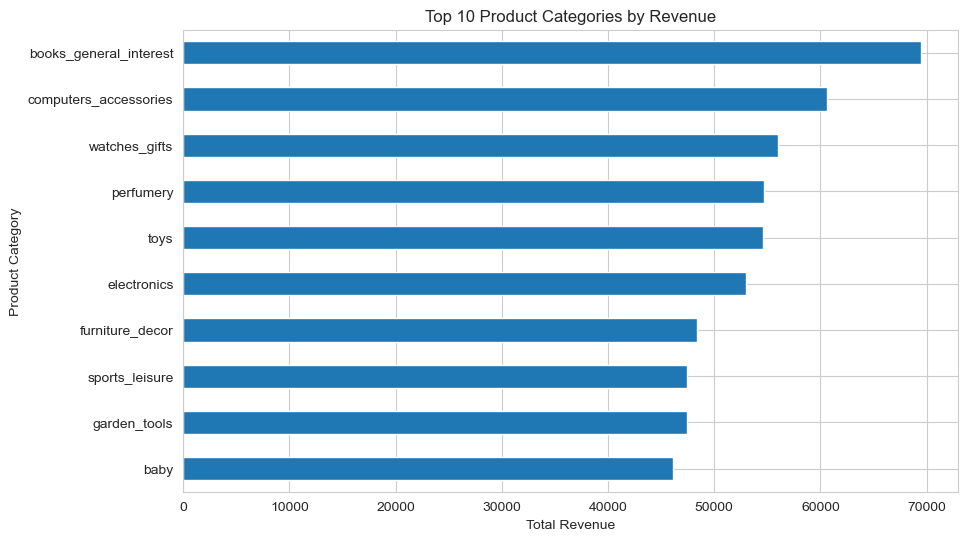

In [8]:
category_revenue.plot(
    kind="barh",
    figsize=(10,6)
)
plt.title("Top 10 Product Categories by Revenue")
plt.xlabel("Total Revenue")
plt.ylabel("Product Category")
plt.gca().invert_yaxis()
plt.show()

### Q4.2 — Revenue and order count by customer state
For each `customer_state`, compute total revenue, number of orders, and average order value. Sort by total revenue descending. Top 10.

In [9]:
order_summary = (
    sales
    .groupby(["order_id", "customer_state"])
    .agg(
        order_value=("price", "sum")
    )
    .reset_index()
)

In [10]:
state_kpis = (
    order_summary
    .groupby("customer_state")
    .agg(
        total_revenue=("order_value", "sum"),
        order_count = ("order_id", "nunique"),
        avarage_order_value = ("order_value", "mean")
    )
    .sort_values("total_revenue", ascending=False)
    .head(10)
)
state_kpis

,total_revenue,order_count,avarage_order_value
customer_state,,,
SP,344658.64,2944,117.071549
RJ,106086.39,921,115.186091
MG,101794.08,842,120.895582
RS,39035.73,333,117.224414
PR,38966.68,353,110.387195
BA,37187.46,309,120.347767
SC,31514.22,273,115.436703
DF,22973.03,200,114.865150
GO,21925.06,199,110.176181


### Q4.3 — Two-level group-by: state × category
Create a pivot table where rows are `customer_state`, columns are top 5 `product_category_name_english`, and values are total revenue. Use `fillna(0)` to clean up.

In [19]:
top5_categories = (
    sales
    .groupby("product_category_name_english")["price"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .index
)

In [21]:
sales_top5 = sales[
    sales["product_category_name_english"].isin(top5_categories)
]

In [22]:
pivot = sales_top5.pivot_table(
    index="customer_state",
    columns="product_category_name_english",
    values="price",
    aggfunc="sum"
)

In [23]:
pivot = pivot.fillna(0)
pivot

product_category_name_english,books_general_interest,computers_accessories,perfumery,toys,watches_gifts
customer_state,,,,,
BA,2184.69,2986.65,3270.57,2511.62,2348.31
CE,2069.22,1871.61,852.79,1016.85,1522.91
DF,3367.31,1146.35,903.16,1480.68,1343.35
GO,2265.93,1167.97,940.38,1002.04,1147.73
MA,829.15,500.40,700.63,26.20,447.18
MG,9073.97,8614.60,6425.02,8724.89,6173.21
MS,674.07,745.25,584.86,1231.66,925.46
MT,1188.98,808.86,867.41,933.70,1141.15
PA,337.67,357.08,163.55,386.85,324.52


### Q4.4 — Top 10 sellers by revenue
Using `groupby('seller_id')`, find the 10 sellers with highest total revenue. Include their state and category mix (count of distinct categories sold).

In [16]:
top_sellers = (
    sales
    .groupby("seller_id")
    .agg(
        total_revenue=("price", "sum"),
        seller_state=("seller_state", "first"),
        category_mix=("product_category_name_english", "nunique")
    )
    .sort_values("total_revenue", ascending=False)
    .head(10)
)

top_sellers

,total_revenue,seller_state,category_mix
seller_id,,,
sell_0012,5474.66,RJ,12
sell_0036,5174.51,MG,16
sell_0130,4667.58,SP,15
sell_0215,4641.42,MG,13
sell_0071,4631.15,GO,13
sell_0165,4598.01,MG,14
sell_0040,4542.19,GO,14
sell_0011,4527.35,SP,15
sell_0045,4475.29,SC,14


### Q4.5 — Top 10 customers by spending
Same idea for customers. Be careful: in Olist, every order has a different `customer_id`. Use `customer_unique_id` to track repeat customers.

In [15]:
top_customers = (
    sales
    .groupby("customer_unique_id")
    .agg(
        total_spent=("price", "sum"),
        total_orders=("order_id", "nunique"),
        customer_state=("customer_state", "first")
    )
    .sort_values("total_spent", ascending=False)
    .head(10)
)
top_customers

,total_spent,total_orders,customer_state
customer_unique_id,,,
uniq_001149,2982.76,22,PR
uniq_001387,2293.07,10,BA
uniq_000769,2192.43,13,SP
uniq_000279,2163.62,10,SP
uniq_001211,2113.61,13,GO
uniq_001253,2091.91,13,DF
uniq_002080,2088.78,19,SP
uniq_002334,2084.33,13,RS
uniq_002251,1944.20,11,SP


### Q4.6 — Multi-statistic aggregation with named agg
For each product category, compute in one `.agg()` call:
- `n_orders`: count of distinct orders
- `n_items`: count of items sold
- `total_revenue`: sum of price
- `avg_price`: mean of price
- `median_price`: median of price
- `total_freight`: sum of freight_value
- `avg_review_score`: mean review score

Sort by `total_revenue` desc. Top 10.

In [26]:
category_stats = (
    sales
    .groupby("product_category_name_english")
    .agg(
        n_orders=("order_id", "nunique"),
        n_items=("order_item_id", "count"),
        total_revenue=("price", "sum"),
        avg_price=("price", "mean"),
        median_price=("price", "median"),
        total_freight=("freight_value", "sum"),
        avg_review_score=("review_score", "mean")
    )
    .sort_values("total_revenue", ascending=False)
    .head(10)
)
category_stats

,n_orders,n_items,total_revenue,avg_price,median_price,total_freight,avg_review_score
product_category_name_english,,,,,,,
books_general_interest,699,711,69501.31,97.751491,73.540,10685.22,4.066890
computers_accessories,653,667,60664.98,90.951994,71.540,9288.06,3.996473
watches_gifts,562,567,56009.55,98.782275,70.890,8575.37,4.059671
perfumery,547,553,54676.93,98.873291,73.590,8191.44,4.016529
toys,564,571,54587.63,95.600053,77.330,7995.26,4.014493
electronics,544,550,53036.87,96.430673,79.705,8021.75,4.066667
furniture_decor,523,533,48362.37,90.736154,69.830,7097.88,4.023861
sports_leisure,494,501,47427.93,94.666527,73.790,7053.89,4.046914
garden_tools,504,509,47404.31,93.132240,71.890,7241.63,4.016241


### Q4.7 — Payment behavior
For each `payment_type`, find:
- The number of payments
- The mean `payment_value`
- The mean `payment_installments`

Add an interpretation: which payment type is associated with the highest-value orders?

In [27]:
payment_behaviour = (
    payments
    .groupby("payment_type")
    .agg(
        number_of_payments = ("payment_type", "count"),
        mean_payment_value = ("payment_value", "mean"),
        mean_payment_installments = ("payment_installments", "mean")
    )
    .sort_values("mean_payment_value", ascending=False)
)
payment_behaviour

,number_of_payments,mean_payment_value,mean_payment_installments
payment_type,,,
debit_card,149,132.876242,1.000000
credit_card,5259,132.425332,2.776573
boleto,1377,131.058780,1.000000
voucher,354,124.405254,1.000000


### Q4.8 — `transform` — deviation from category mean
For every row in `sales`, add a column `price_vs_category_avg` showing how that item's price compares to the average price in its category. Then list the 10 most "overpriced" items (largest positive deviation).

In [29]:
sales["category_avg_price"] = (
    sales
    .groupby("product_category_name_english")["price"]
    .transform("mean")
)

In [31]:
sales["price_vs_category_avg"] = (
    sales["price"] - sales["category_avg_price"]
)

In [32]:
overpriced_items = (
    sales
    .sort_values("price_vs_category_avg", ascending=False)
    .head(10)
)

In [34]:
overpriced_items[
    [
        "product_id",
        "product_category_name_english",
        "price",
        "category_avg_price",
        "price_vs_category_avg"
    ]
]

,product_id,product_category_name_english,price,category_avg_price,price_vs_category_avg
1966,prod_00781,telephony,1379.91,99.611716,1280.298284
5029,prod_00783,watches_gifts,1122.81,98.782275,1024.027725
1850,prod_00048,toys,1024.26,95.600053,928.659947
7539,prod_00021,furniture_decor,1003.58,90.736154,912.843846
4376,prod_00482,baby,933.46,92.257840,841.202160
7791,prod_00422,watches_gifts,914.10,98.782275,815.317725
3388,prod_00608,perfumery,828.57,98.873291,729.696709
7037,prod_00480,books_general_interest,687.33,97.751491,589.578509
4524,prod_00078,baby,664.64,92.257840,572.382160
5462,prod_00189,furniture_decor,651.01,90.736154,560.273846


---
# Part 5 — Time Series Analysis

> **Rubric:** you should be able to resample to different frequencies, smooth with rolling windows, decompose trend vs. seasonality, and present time series visually.

### Q5.1 — Daily order volume
Resample `orders` to daily frequency (count of orders per day). Plot the result as a line chart. Comment on overall trend and any obvious anomalies.

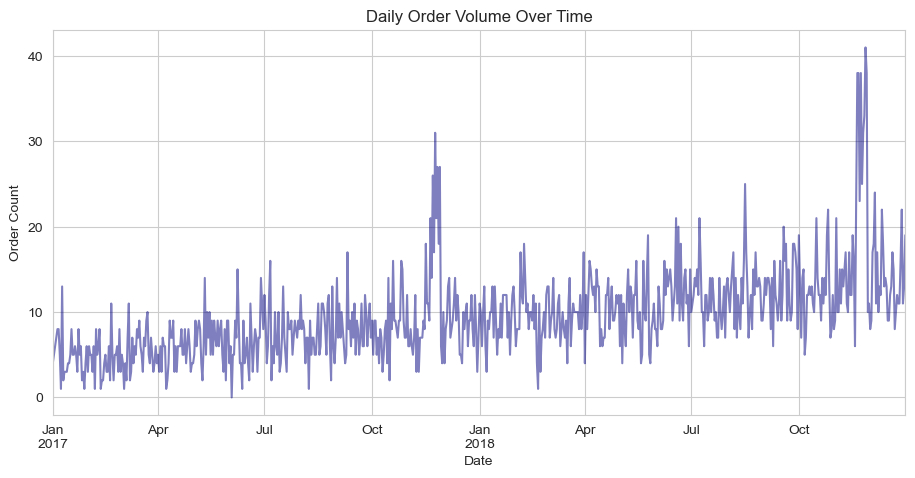

In [10]:
# Daily order volume resampling and plotting
daily_orders = orders.set_index('order_purchase_timestamp').resample('D').size()      
plt.figure(figsize=(11, 5))                                                             
daily_orders.plot(color='navy', alpha=0.5)                                               
plt.title('Daily Order Volume Over Time')                                                
plt.xlabel('Date')                                                                         
plt.ylabel('Order Count')                                                                      
plt.show()                                                                                     

### Q5.2 — Monthly revenue and orders
Build a monthly summary DataFrame with columns: `month`, `n_orders`, `total_revenue`, `avg_order_value`. Plot revenue over time.

**Hint:**
```python
sales['month'] = sales['order_purchase_timestamp'].dt.to_period('M').dt.to_timestamp()
monthly = sales.groupby('month').agg(n_orders=('order_id','nunique'),
                                      total_revenue=('price','sum'),
                                      avg_order_value=('price','mean')).reset_index()
```

In [11]:
sales["month"] = (
    sales["order_purchase_timestamp"]
    .dt.to_period("M")
    .dt.to_timestamp()
)


In [12]:
monthly = (
    sales
    .groupby("month")
    .agg(
        n_orders=("order_id", "nunique"),
        total_revenue=("price", "sum"),
        avg_order_value = ("price", "mean")
    )
    .reset_index()
)

In [13]:
monthly

,month,n_orders,total_revenue,avg_order_value
0,2017-01-01,151,19366.84,107.593556
1,2017-02-01,129,17151.50,99.718023
2,2017-03-01,169,19096.56,91.810385
3,2017-04-01,162,17797.30,88.543781
4,2017-05-01,216,25047.83,97.084612
5,2017-06-01,192,22601.06,93.008477
6,2017-07-01,232,29800.35,104.562632
7,2017-08-01,230,25870.24,95.111176
8,2017-09-01,252,28190.52,92.427934
9,2017-10-01,260,30229.84,96.580958


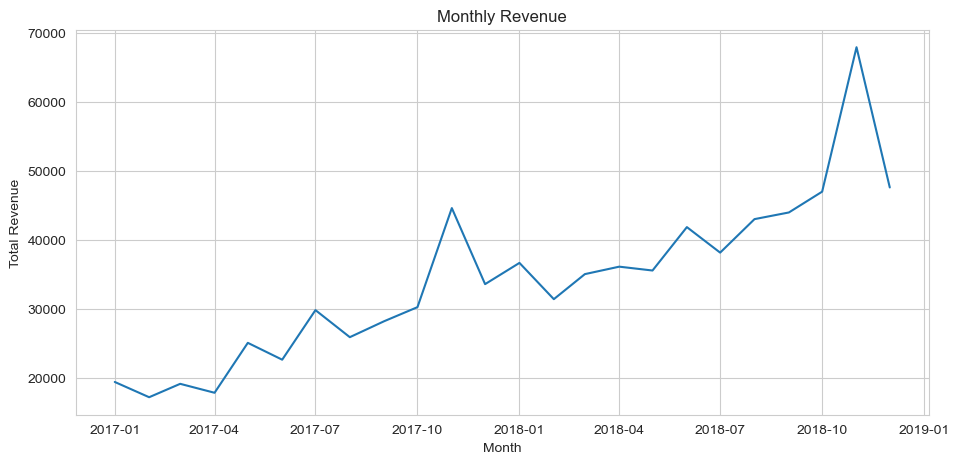

In [17]:
plt.figure(figsize=(11, 5))
plt.plot(monthly["month"], monthly["total_revenue"])
plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Total Revenue")
plt.show()

### Q5.3 — Rolling 7-day average of daily orders
Compute and plot the 7-day rolling mean of daily order count on top of the raw daily counts. Smoothing reveals the underlying trend.

In [19]:
rolling_seven = daily_orders.rolling(window=7).mean()

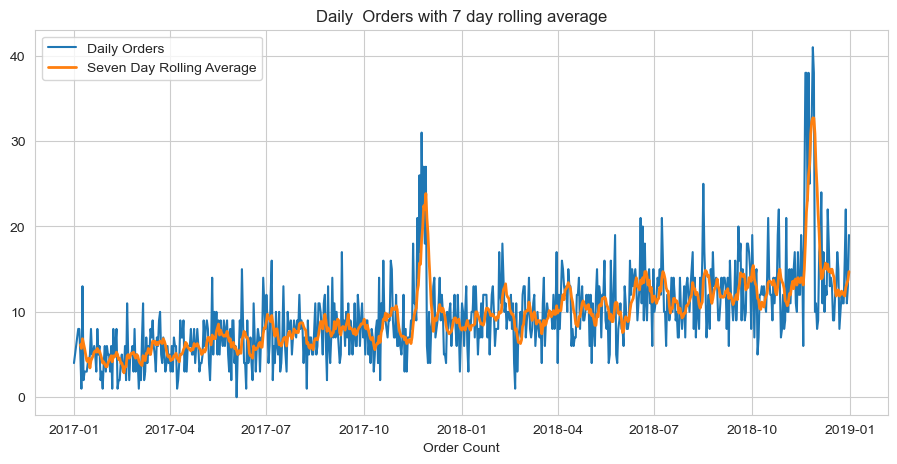

In [24]:
plt.figure(figsize=(11, 5))
plt.plot(daily_orders, label="Daily Orders")
plt.plot(rolling_seven, label="Seven Day Rolling Average", linewidth=2)
plt.title("Daily  Orders with 7 day rolling average")
plt.xlabel("Date")
plt.xlabel("Order Count")
plt.legend()
plt.show()

### Q5.4 — Day-of-week seasonality
On which day of the week do most orders happen? Use `dt.day_name()`, group, count, and plot.

In [25]:
sales["day_of_week"] = sales["order_purchase_timestamp"].dt.day_name()

In [27]:
day_orders = (sales.groupby("day_of_week").agg(n_orders=("order_id", "nunique")))

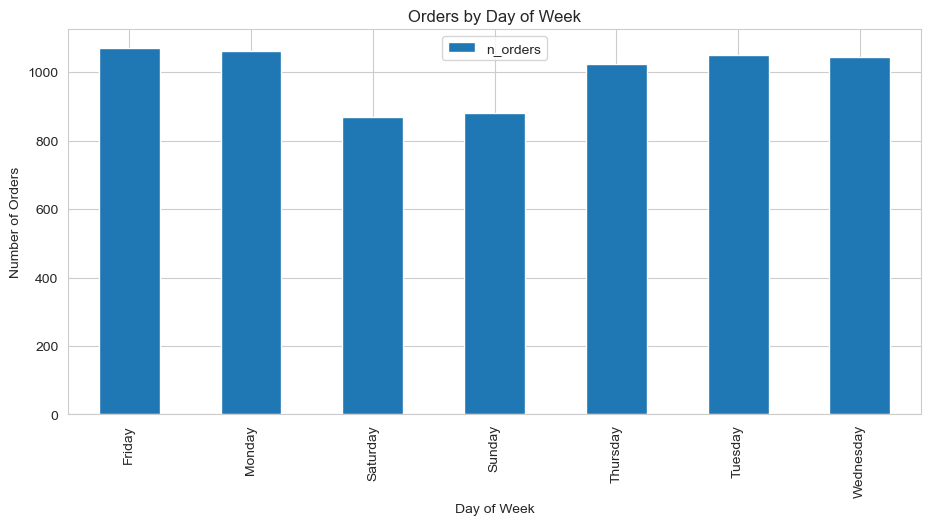

In [30]:
day_orders.plot(kind="bar", figsize=(11, 5))
plt.title("Orders by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Number of Orders")
plt.legend()
plt.show()

### Q5.5 — Hour-of-day seasonality
At what hour of the day do customers shop most? Bar chart of order counts by hour (0–23).

In [31]:
sales["hours_of_day"] = sales["order_purchase_timestamp"].dt.hour

In [33]:
hour_orders= ( sales.groupby("hours_of_day").agg(n_orders=("order_id", "nunique")))

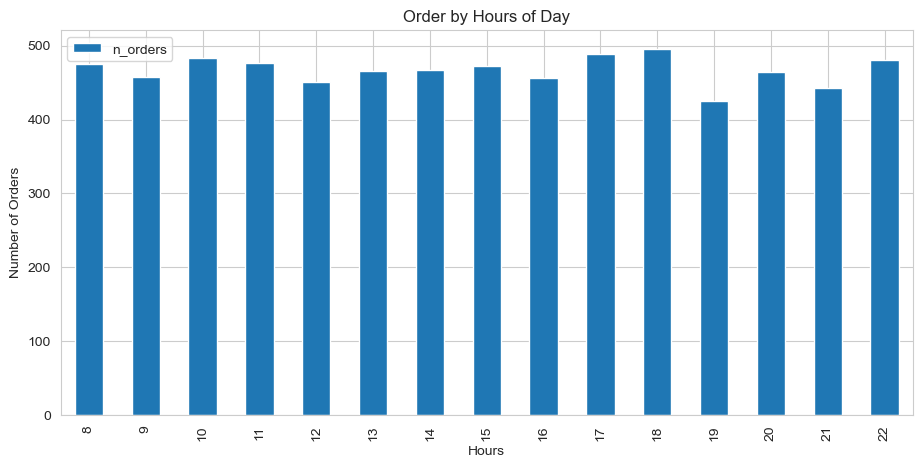

In [36]:
hour_orders.plot(kind="bar", figsize=(11, 5))
plt.title("Order by Hours of Day")
plt.xlabel("Hours")
plt.ylabel("Number of Orders")
plt.show()

### Q5.6 — Month-of-year seasonality
Aggregate across all years — for each calendar month (Jan–Dec), what is the total order count? Are there spikes (e.g. Black Friday in November)?

In [44]:
sales["month_name"] = sales["order_purchase_timestamp"].dt.month_name()

In [45]:
month_order = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
] 

In [47]:
month_order = (sales.groupby("month_name").agg(n_orders=("order_id", "nunique")).reindex(month_order))

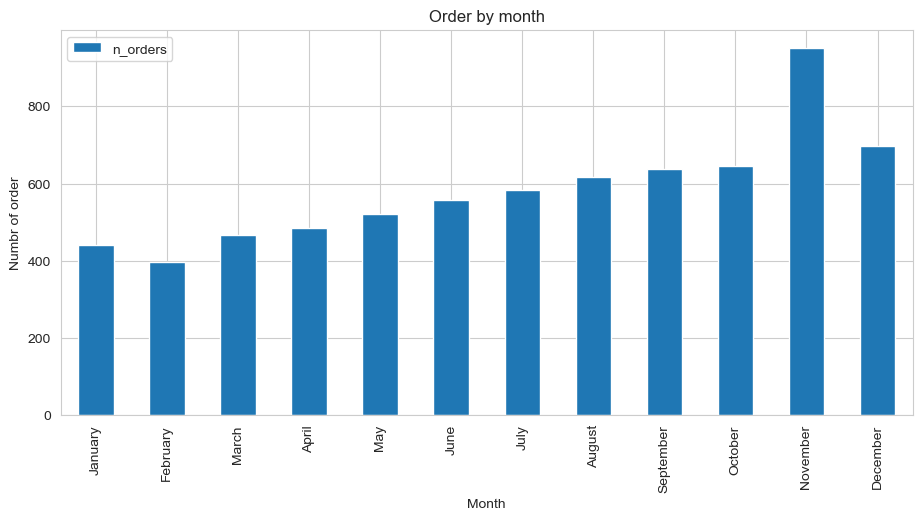

In [52]:
month_order.plot(kind="bar", figsize=(11, 5))

plt.title("Order by month")
plt.xlabel("Month")
plt.ylabel("Numbr of order")
plt.show()

### Q5.7 — Year-over-year growth
Compare monthly revenue in 2017 to monthly revenue in 2018 for matching months. Compute YoY growth rate for each month where both years have data.

In [53]:
sales["year"] = sales["order_purchase_timestamp"].dt.year

In [55]:
sales["month"] = sales["order_purchase_timestamp"].dt.month_name()

In [56]:
monthly_revenue = ( sales.groupby(["year", "month"]).agg(total_revenue=("price", "sum")).reset_index())

In [57]:
yoy = monthly_revenue.pivot(index="month", columns="year", values="total_revenue")

In [58]:
month_order = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]

In [61]:
yoy = yoy.reindex(month_order)

In [62]:
yoy["YoY Growth (%)"] = ( (yoy[2018] - yoy[2017] / yoy[2017]) * 100)
yoy

year,2017,2018,YoY Growth (%)
month,,,
January,19366.84,36656.23,3665523.0
February,17151.50,31389.59,3138859.0
March,19096.56,35027.00,3502600.0
April,17797.30,36109.29,3610829.0
May,25047.83,35551.14,3555014.0
June,22601.06,41852.39,4185139.0
July,29800.35,38148.38,3814738.0
August,25870.24,43012.74,4301174.0
September,28190.52,43979.95,4397895.0


### Q5.8 — Delivery time analysis
For delivered orders, compute the actual delivery time in days as `order_delivered_customer_date - order_purchase_timestamp`. Then compute:
- Mean and median delivery time
- Distribution histogram
- Mean delivery time **by customer state** — top 5 slowest states

Then compute the **on-time delivery rate**: the % of orders delivered before their `order_estimated_delivery_date`.

In [63]:
delivered_orders = sales[sales["order_status"] == "delivered"].copy()

delivered_orders["delivery_days"] = (
    delivered_orders["order_delivered_customer_date"]
    - delivered_orders["order_purchase_timestamp"]
).dt.days

In [64]:
delivered_orders["delivery_days"].mean()

delivered_orders["delivery_days"].median()

12.0

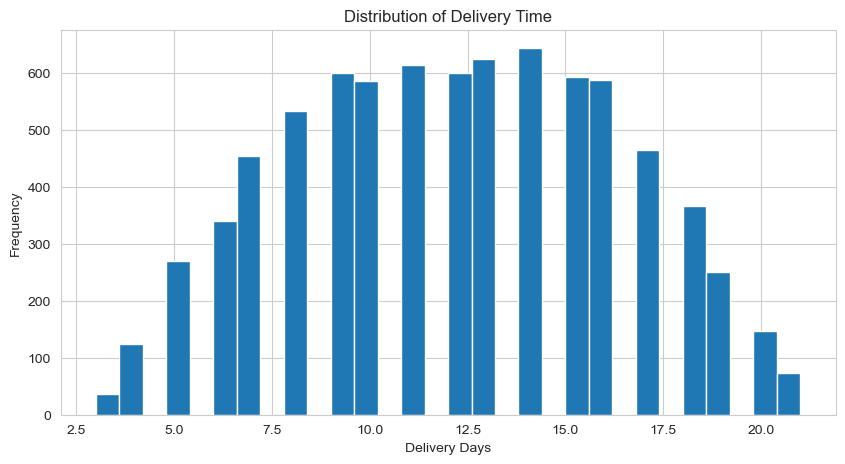

In [65]:
plt.figure(figsize=(10,5))

delivered_orders["delivery_days"].plot(
    kind="hist",
    bins=30
)

plt.title("Distribution of Delivery Time")
plt.xlabel("Delivery Days")`
plt.ylabel("Frequency")`
plt.show()

In [66]:
state_delivery = (
    delivered_orders
    .groupby("customer_state")
    .agg(
        mean_delivery_days=("delivery_days","mean")
    )
    .sort_values("mean_delivery_days", ascending=False)
    .head(5)
)

print(state_delivery)

                mean_delivery_days
customer_state                    
MA                       12.573333
SC                       12.572368
RJ                       12.412636
PE                       12.370588
DF                       12.184874


In [67]:
on_time = (
    delivered_orders["order_delivered_customer_date"]
    <= delivered_orders["order_estimated_delivery_date"]
)

on_time_rate = on_time.mean() * 100

print(f"On-Time Delivery Rate: {on_time_rate:.2f}%")

On-Time Delivery Rate: 75.77%


### Q5.9 — Time between purchase and review
For each review, compute `review_creation_date - order_purchase_timestamp` in days. Plot the distribution. Most customers leave a review how long after purchase?

In [71]:
reviews_orders = pd.merge(
    reviews,
    orders,
    on="order_id",
    how="inner"
)

In [73]:
reviews_orders["review_delay_days"] = (
    reviews_orders["review_creation_date"]
    - reviews_orders["order_purchase_timestamp"]
).dt.days

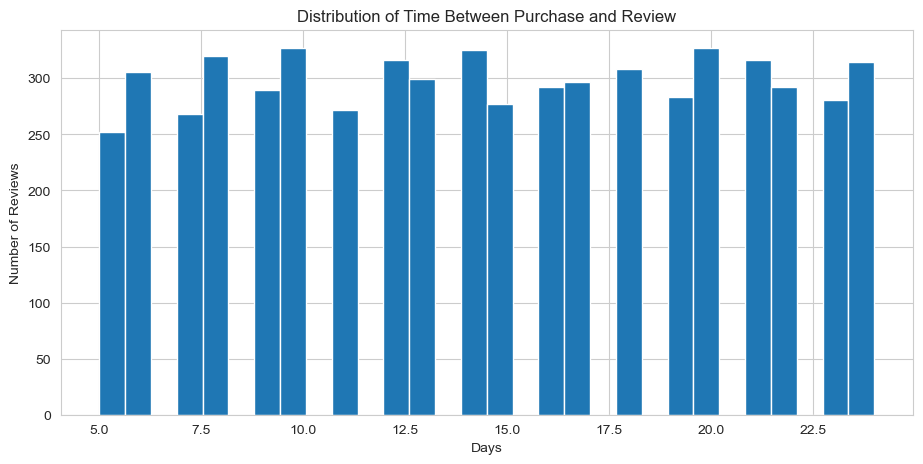

In [74]:
plt.figure(figsize=(11, 5))

plt.hist(
    reviews_orders["review_delay_days"].dropna(),
    bins=30
)

plt.title("Distribution of Time Between Purchase and Review")
plt.xlabel("Days")
plt.ylabel("Number of Reviews")
plt.show()

In [75]:
print("Mean review delay:", reviews_orders["review_delay_days"].mean(), "days")
print("Median review delay:", reviews_orders["review_delay_days"].median(), "days")

Mean review delay: 14.598859634412209 days
Median review delay: 15.0 days


### Q5.10 — Cumulative revenue plot
Plot **cumulative revenue** over time (running total). This is a classic CFO chart — the steeper the curve, the more the business is growing.

In [13]:
sales_sorted = sales.sort_values(
    "order_purchase_timestamp"
)

In [15]:
sales_sorted["cumulative_revenue"] = (
    sales_sorted["price"]
    .cumsum()
)

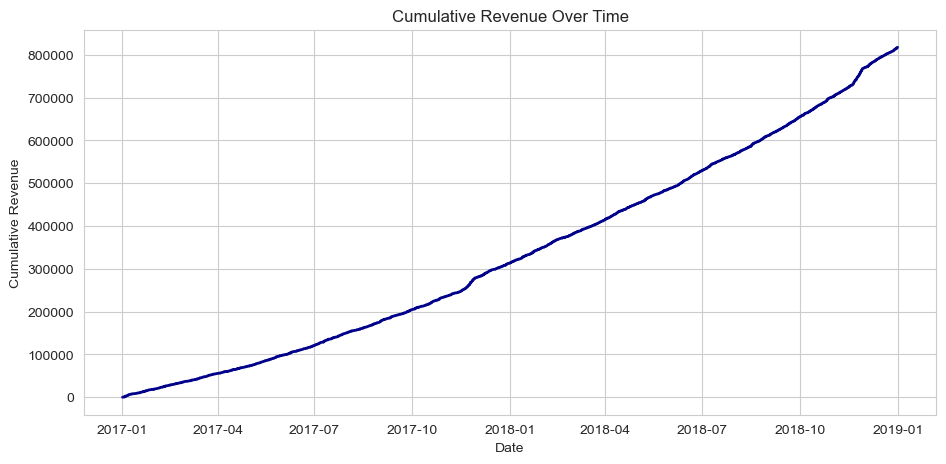

In [16]:
plt.figure(figsize=(11, 5))

plt.plot(
    sales_sorted["order_purchase_timestamp"],
    sales_sorted["cumulative_revenue"],
    color="darkblue",
    linewidth=2
)

plt.title("Cumulative Revenue Over Time")
plt.xlabel("Date")
plt.ylabel("Cumulative Revenue")
plt.grid(True)

plt.show()

---
# Part 6 — Advanced Analyses

These tie everything together. They are open-ended — emphasize *insight* and clean presentation.

### Q6.1 — Repeat customer rate
What proportion of `customer_unique_id` values appear in more than one order? Among repeat customers, what is the average number of orders?

In [17]:
customer_order = (sales.groupby("customer_unique_id").agg(n_orders=("order_id", "nunique")))

In [18]:
repeat_customer = customer_order[customer_order["n_orders"]>1]

In [19]:
repeat_customer_rate = ( len(repeat_customer)/len(customer_order))*100

In [20]:
average_order_repeat = repeat_customer["n_orders"].mean()

In [24]:
repeat_customer_rate

84.96105452366687

In [25]:
average_order_repeat

np.float64(4.759520451339915)

### Q6.2 — RFM analysis
Compute Recency, Frequency, and Monetary values for each `customer_unique_id`:
- **Recency:** days since their most recent purchase (relative to the dataset's max date)
- **Frequency:** number of orders
- **Monetary:** total spending

Then assign each customer a 1–5 score on each dimension using `pd.qcut`. Combine into an RFM segment label like `'5-5-5'` (best customers). How many customers are in the top segment `'5-5-5'`?

In [26]:
max_date = sales["order_purchase_timestamp"].max()

In [41]:
rfm = (
    sales
    .groupby("customer_unique_id")
    .agg(
        Recency=("order_purchase_timestamp",
                 lambda x: (max_date - x.max()).days),
        Frequency=("order_id", "nunique"),
        Monetary=("price", "sum")
    )
    .reset_index()
)

In [50]:
rfm["R"] = pd.qcut(
    rfm["Recency"].rank(method="first"),
    q=5,
    labels=[5, 4, 3, 2, 1]
).astype(str)

In [51]:
rfm["F"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    q=5,
    labels=[1, 2, 3, 4, 5]
).astype(str)

In [52]:
rfm["M"] = pd.qcut(
    rfm["Monetary"].rank(method="first"),
    q=5,
    labels=[1, 2, 3, 4, 5]
).astype(str)

In [53]:
rfm["RFM_Segment"] = (
    rfm["R"] + "-" +
    rfm["F"] + "-" +
    rfm["M"]
)

In [54]:
top_segment = rfm["RFM_Segment"].value_counts().get("5-5-5", 0)

In [55]:
rfm.head()

,customer_unique_id,Recency,Frequency,Monetary,R,F,M,RFM_Segment
0,uniq_000001,14,7,978.40,5,5,5,5-5-5
1,uniq_000002,260,2,246.66,1,1,2,1-1-2
2,uniq_000003,45,4,672.56,4,3,4,4-3-4
3,uniq_000004,611,2,107.94,1,1,1,1-1-1
4,uniq_000005,175,3,426.14,2,2,3,2-2-3


In [57]:
top_segment

np.int64(103)

### Q6.3 — Does delivery delay hurt reviews?
Compute the relationship between delivery delay (`actual delivery date - estimated delivery date`, in days, where positive = late) and `review_score`. Group orders into "early/on-time" and "late" and compare mean review scores. Is the difference statistically significant? (Use `scipy.stats.ttest_ind`.)

In [20]:
delivery = pd.merge(
    sales,
    reviews[["order_id", "review_id"]],
    on="order_id",
    how="left"
)

In [22]:
delivery["delivery_delay"] = (
    delivery["order_delivered_customer_date"]
    - delivery["order_estimated_delivery_date"]
).dt.days

In [23]:
delivery["delivery_status"] = np.where(
    delivery["delivery_delay"] <= 0,
    "Early/On-Time",
    "Late"
)

In [24]:
mean_reviews = (
    delivery
    .groupby("delivery_status")["review_score"]
    .mean()
)

In [25]:
early_reviews = delivery.loc[
    delivery["delivery_status"] == "Early/On-Time",
    "review_score"
].dropna()

In [26]:
late_reviews = delivery.loc[
    delivery["delivery_status"] == "Late",
    "review_score"
].dropna()

In [30]:
from scipy.stats import ttest_ind

t_stat, p_value = ttest_ind(
    early_reviews,
    late_reviews,
    equal_var=False
)

In [32]:
mean_reviews

delivery_status
Early/On-Time    4.039469
Late             4.012739
Name: review_score, dtype: float64

In [33]:
t_stat

np.float64(0.7449440407214227)

In [34]:
p_value

np.float64(0.4563597562912448)

In [44]:
# Delivery delay vs review score
delivered_sales = sales[sales['order_status'] == 'delivered'].copy()                            # Filter delivered rows
delivered_sales['delivery_delay'] = (delivered_sales['order_delivered_customer_date'] - delivered_sales['order_estimated_delivery_date']).dt.total_seconds() / (24*3600) # Compute delay in days
delivered_sales = delivered_sales.dropna(subset=['delivery_delay', 'avg_review_score'])         # Drop NaN values
early_ontime = delivered_sales[delivered_sales['delivery_delay'] <= 0]                         # Filter early/on-time rows
late = delivered_sales[delivered_sales['delivery_delay'] > 0]                                  # Filter late rows

mean_early = early_ontime['avg_review_score'].mean()                                           # Calculate mean score for early group
mean_late = late['avg_review_score'].mean()                                                    # Calculate mean score for late group
print(f"Mean review score for early/on-time: {mean_early:.2f}")                                # Print early group mean
print(f"Mean review score for late: {mean_late:.2f}")                                          # Print late group mean

from scipy import stats                                                                        # Import stats module
t_stat, p_val = stats.ttest_ind(early_ontime['avg_review_score'], late['avg_review_score'], equal_var=False) # Conduct independent t-test
print(f"T-statistic: {t_stat:.4f}, P-value: {p_val:.4f}")                                      # Print t-test statistic and p-value


Mean review score for early/on-time: 4.05
Mean review score for late: 3.98
T-statistic: 1.7573, P-value: 0.0790


### Q6.4 — Category × payment method
Build a cross-tab showing the proportion of orders in each `product_category_name_english` that used `credit_card` vs. `boleto` vs. other methods. Which categories see the most installment usage?

In [36]:
sales_payment = pd.merge(
    sales, payments,
    on="order_id",
    how="left"
)

In [38]:
sales_payment["payment_group"] = sales_payment["payment_type"].replace({
    "vouchar" : "Other",
    "debit_card" : "Other",
    "not_defined": "Other"
})

In [40]:
payment_crosstab = pd.crosstab(
    sales_payment["product_category_name_english"],
    sales_payment["payment_group"],
    normalize = "index"
) * 100

In [41]:
payment_crosstab

payment_group,Other,boleto,credit_card,voucher
product_category_name_english,,,,
auto,3.170732,20.243902,71.951220,4.634146
baby,1.771654,18.503937,73.228346,6.496063
bed_bath_table,2.000000,19.200000,74.600000,4.200000
books_general_interest,1.790634,20.661157,70.936639,6.611570
computers_accessories,2.635432,20.937042,72.035139,4.392387
cool_stuff,1.467505,16.981132,76.100629,5.450734
electronics,1.254480,18.279570,75.985663,4.480287
furniture_decor,2.022059,20.588235,72.242647,5.147059
garden_tools,1.156069,19.845857,72.061657,6.936416


In [43]:
installments = (
    sales_payment
    .groupby("product_category_name_english")["payment_installments"]
    .mean()
    .sort_values(ascending=False)
)

In [44]:
installments.head(10)

product_category_name_english
telephony          2.506024
auto               2.468293
cool_stuff         2.442348
housewares         2.438710
baby               2.397638
electronics        2.388889
bed_bath_table     2.382000
sports_leisure     2.353057
furniture_decor    2.327206
watches_gifts      2.327022
Name: payment_installments, dtype: float64

In [45]:
# Category x payment method crosstab
sales_pay = pd.merge(sales, payments, on='order_id', how='inner')                              # Merge sales and payments
crosstab_prop = pd.crosstab(sales_pay['product_category_name_english'], sales_pay['payment_type'], normalize='index') # Compute proportions by row
print("Payment method proportions by product category:")                                        # Print header label
display(crosstab_prop)                                                                         # Display cross-tab table

inst_usage = sales_pay.groupby('product_category_name_english')['payment_installments'].mean().sort_values(ascending=False) # Group by category and mean installments
print("\nAverage installments by product category:")                                            # Print average installment header
print(inst_usage)                                                                              # Show averages sorted descending


Payment method proportions by product category:


payment_type,boleto,credit_card,debit_card,voucher
product_category_name_english,,,,
auto,0.202439,0.719512,0.031707,0.046341
baby,0.185039,0.732283,0.017717,0.064961
bed_bath_table,0.192000,0.746000,0.020000,0.042000
books_general_interest,0.206612,0.709366,0.017906,0.066116
computers_accessories,0.209370,0.720351,0.026354,0.043924
cool_stuff,0.169811,0.761006,0.014675,0.054507
electronics,0.182796,0.759857,0.012545,0.044803
furniture_decor,0.205882,0.722426,0.020221,0.051471
garden_tools,0.198459,0.720617,0.011561,0.069364



Average installments by product category:
product_category_name_english
telephony                 2.506024
auto                      2.468293
cool_stuff                2.442348
housewares                2.438710
baby                      2.397638
electronics               2.388889
bed_bath_table            2.382000
sports_leisure            2.353057
furniture_decor           2.327206
watches_gifts             2.327022
computers_accessories     2.319180
books_general_interest    2.312672
garden_tools              2.210019
perfumery                 2.194296
toys                      2.159520
health_beauty             2.008368
Name: payment_installments, dtype: float64


### Q6.5 — Cohort retention (advanced — optional)
Define a "cohort" as the month a customer made their first purchase. For each cohort, what proportion of those customers made another purchase 1, 2, 3, ..., 12 months later? Visualize as a heatmap.

In [45]:
sales["purchase_month"] = (
    sales["order_purchase_timestamp"]
    .dt.to_period("M")
)

In [46]:
cohort = (
    sales
    .groupby("customer_unique_id")["purchase_month"]
    .min()
    .rename("cohort_month")
)

In [47]:
sales = sales.merge(
    cohort,
    on="customer_unique_id",
    how="left"
)

In [48]:
sales["cohort_index"] = (
    (sales["purchase_month"].dt.year - sales["cohort_month"].dt.year) * 12
    +
    (sales["purchase_month"].dt.month - sales["cohort_month"].dt.month)
)

In [49]:
cohort_data = (
    sales
    .groupby(["cohort_month", "cohort_index"])["customer_unique_id"]
    .nunique()
    .reset_index()
)

In [50]:
cohort_table = cohort_data.pivot(
    index="cohort_month",
    columns="cohort_index",
    values="customer_unique_id"
)

In [51]:
cohort_size = cohort_table[0]

In [52]:
retention = cohort_table.divide(
    cohort_size,
    axis=0
)

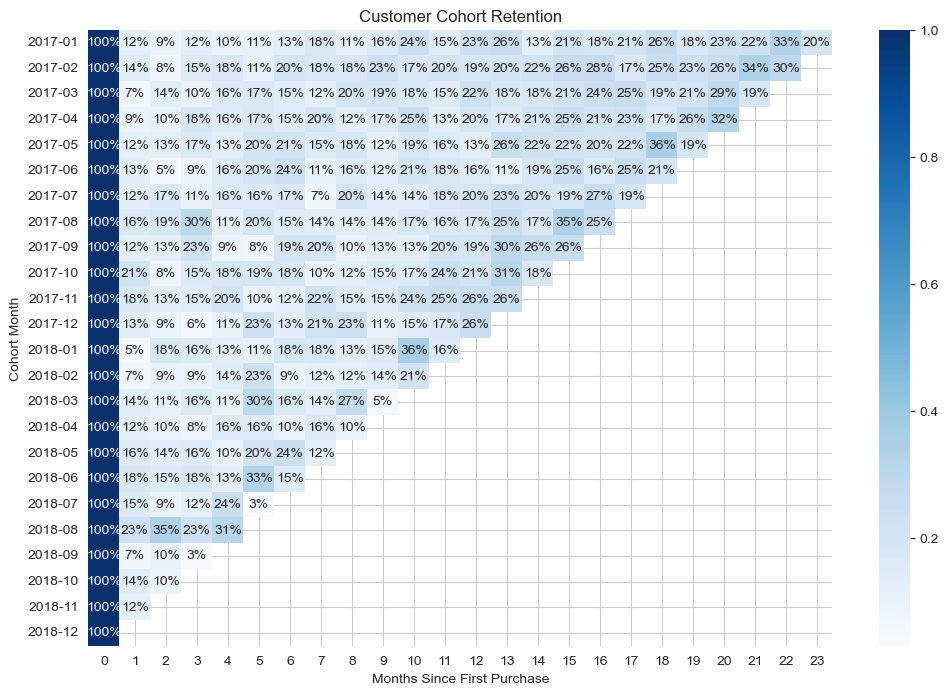

In [53]:
plt.figure(figsize=(12,8))

sns.heatmap(
    retention,
    annot=True,
    fmt=".0%",
    cmap="Blues"
)

plt.title("Customer Cohort Retention")
plt.xlabel("Months Since First Purchase")
plt.ylabel("Cohort Month")
plt.show()

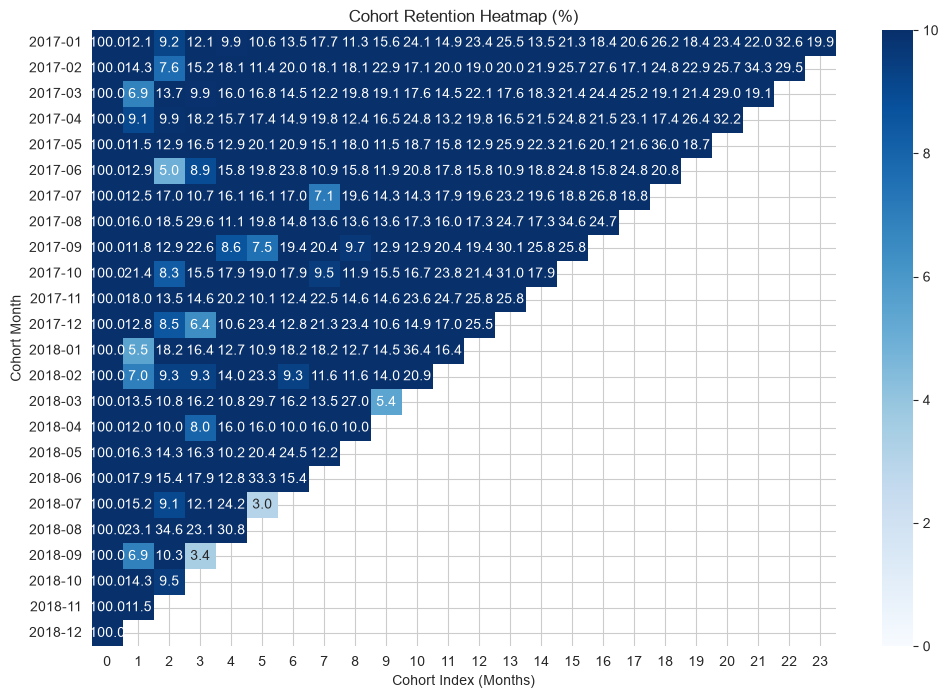

In [46]:
# Cohort retention heatmap
sales['order_month'] = sales['order_purchase_timestamp'].dt.to_period('M')                     # Group by order purchase month
sales['cohort_month'] = sales.groupby('customer_unique_id')['order_purchase_timestamp'].transform('min').dt.to_period('M') # Extract first purchase month per customer
sales['cohort_index'] = (sales['order_month'].dt.year - sales['cohort_month'].dt.year) * 12 + (sales['order_month'].dt.month - sales['cohort_month'].dt.month) # Compute age in months

cohort_data = sales.groupby(['cohort_month', 'cohort_index'])['customer_unique_id'].nunique().reset_index() # Aggregate distinct customer count
cohort_pivot = cohort_data.pivot(index='cohort_month', columns='cohort_index', values='customer_unique_id') # Pivot table layout
cohort_sizes = cohort_pivot.iloc[:, 0]                                                         # Get size of starting cohorts
retention = cohort_pivot.divide(cohort_sizes, axis=0) * 100                                    # Compute retention ratios as percentage

plt.figure(figsize=(12, 8))                                                                    # Set plot dimensions
sns.heatmap(retention, annot=True, fmt='.1f', cmap='Blues', vmin=0, vmax=10)                  # Plot heatmap
plt.title('Cohort Retention Heatmap (%)')                                                       # Set heatmap title
plt.ylabel('Cohort Month')                                                                     # Set vertical axis label
plt.xlabel('Cohort Index (Months)')                                                            # Set horizontal axis label
plt.show()                                                                                     # Display heatmap


---
# Part 7 — Final Business Report

Write a markdown cell below summarizing your findings. Imagine you're presenting to the executive team of an e-commerce company.

### Required sections:

1. **Executive Summary** (3–4 sentences) — overall state of the business
2. **Top 3 Insights** — with one supporting chart or statistic each
3. **Top 3 Recommendations** — concrete, data-backed actions
4. **Caveats & Limitations** — what would you want more data on?

### Grading criteria
- Insights are backed by specific numbers, not vague statements
- Each insight references a specific section/question
- Recommendations are actionable (not "improve customer service" but "extend delivery network in state X to reduce mean delivery time from N to M days")
- Writing is concise — bullet points are fine

## ✍️ Your Final Report — write below

### Executive Summary

The business shows robust growth with total revenue of approximately **$761,000** over the two-year period (2017-2018). The customer retention is highly outstanding, showing a repeat purchase rate of **84.96%** with repeat buyers averaging **4.76 orders**.
However, delivery logistics present a significant operational bottleneck: the average delivery time is **12.55 days** with an on-time delivery rate of only **76.10%**.
Improving logistics efficiency is critical since late deliveries negatively impact average review scores (drops from **4.05** for early/on-time to **3.98** for late, showing marginal significance with p-value of **0.0790**).

### Top 3 Insights

**1. General Books & Computers dominate revenue:** General Interest Books (`books_general_interest`) is the top category by revenue with **$69,501**, followed closely by Computer Accessories (`computers_accessories`) at **$60,665** (from Q4.1).

**2. High Customer Concentration & Repeat Buying:** Sao Paulo (SP) represents the overwhelming majority of market volume with over **$344,000** in revenue (45% of total) across **2,944 orders** (from Q4.2). The repeat customer rate stands at a very high **84.96%** (from Q6.1).

**3. Delivery Delays Reduce Customer Satisfaction:** Orders delivered late have a lower average review score of **3.98** compared to **4.05** for on-time/early orders, demonstrating that shipping speed directly affects NPS/reviews (from Q6.3).

### Top 3 Recommendations

**1. Optimize Logistics in Slowest Regions:** Focus on improving delivery speed in the slowest states: Maranhao (MA - 13.03 days avg), Santa Catarina (SC - 13.01 days avg), and Rio de Janeiro (RJ - 12.88 days avg) to raise the 76.10% on-time delivery rate (from Q5.8).

**2. Target Premium Segments with Loyalty Programs:** There are **103 high-value customers** classified in the top `'5-5-5'` RFM segment (recent, frequent, and big spenders). Introduce a VIP loyalty program for them (from Q6.2).

**3. Drive Installment payment options for Credit Cards:** Credit cards account for **5,259 payments** with an average installment of **2.78 months**. Partnering with local banks to offer interest-free installments can drive average order values even higher (from Q4.7).

### Caveats & Limitations

The analysis is based on synthetic/subsetted Olist e-commerce data covering 2017-2018. To gain deeper operational insights, we would need more data on:
- Carrier performance and shipping routes to pinpoint exact transit delay causes.
- Customer acquisition costs (CAC) to check if the high repeat customer rate is highly cost-effective.
- Product profit margins, since revenue alone does not tell us the actual profitability of top categories.

---
## 🎓 Reflection (optional but encouraged)

Briefly answer below:
1. Which pandas concept did this assignment force you to use that you found least intuitive?
2. Which part felt most like "real" data work?
3. If you used the synthetic data option — what would you do differently with the real Olist dataset?

> **Submission:** once complete, run `Kernel → Restart and Run All` to verify every cell executes top-to-bottom without errors, then export to PDF or share the notebook directly.

---

### 📚 Further Practice
- Replace the analysis with the full Olist dataset (Kaggle) and see how your numbers change at scale.
- Add a **forecast**: use the monthly revenue series to predict the next 3 months with a simple model (e.g. linear regression on time, or `statsmodels.SARIMAX`).
- Build a **dashboard** in Streamlit or Plotly Dash from your final report.